# Mobilis Telecom - Intent Classification (DistilBERT)
Improved version with diagnostics, leakage checks, and a confidence fallback for the RAG/LLM pipeline.

**What changed vs. the original notebook:**
1. Full classification report + confusion matrix actually printed
2. Misclassified examples inspection (see *what* is being confused with *what*)
3. Near-duplicate leakage check between train/test (Bitext data is heavily templated)
4. Keyword lookup helper to inspect which intent a given word/phrase belongs to
5. Confidence-threshold fallback in the inference loop so low-confidence predictions don't get passed blindly to the LLM

In [1]:
!nvidia-smi


Wed Aug 12 20:35:42 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   55C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 1. Install Required Libraries

In [2]:
!pip install -q transformers datasets accelerate evaluate


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.4 MB/s eta 0:00:00


## 2. Imports

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from difflib import SequenceMatcher
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset
import evaluate


## 3. Load the Dataset

In [4]:
df = pd.read_csv("hf://datasets/bitext/Bitext-telco-llm-chatbot-training-dataset/bitext-telco-llm-chatbot-training-dataset.csv")
df.head()


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


,instruction,intent,category,tags,response
0,there are charges on my phone bill that i do n...,dispute_invoice,BILLING,BCELQZ,If you have noticed discrepancies in your bill...
1,"my internet bill is incorrect, can you help me...",dispute_invoice,BILLING,BCILZ,If there is an issue with your bill and you wo...
2,my invoice is not corect challenge it,dispute_invoice,BILLING,BCELQZ,If you find any discrepancies in your invoice ...
3,"I don't recognize some charges on my bill, can...",dispute_invoice,BILLING,BCIL,If you have found charges on your bill that yo...
4,i have to dispute a fucking bill i need help,dispute_invoice,BILLING,BCQW,If you believe there is an error on your bill ...


## 4. Explore the Dataset

In [5]:
print(df.shape)
print(df.columns)
print(df.isnull().sum())
print("Exact duplicate rows:", df.duplicated().sum())
print("Number of intents:", df["intent"].nunique())
display(df.head())


(26000, 5)
Index(['instruction', 'intent', 'category', 'tags', 'response'], dtype='object')
instruction    0
intent         0
category       0
tags           0
response       0
dtype: int64
Exact duplicate rows: 0
Number of intents: 26


,instruction,intent,category,tags,response
0,there are charges on my phone bill that i do n...,dispute_invoice,BILLING,BCELQZ,If you have noticed discrepancies in your bill...
1,"my internet bill is incorrect, can you help me...",dispute_invoice,BILLING,BCILZ,If there is an issue with your bill and you wo...
2,my invoice is not corect challenge it,dispute_invoice,BILLING,BCELQZ,If you find any discrepancies in your invoice ...
3,"I don't recognize some charges on my bill, can...",dispute_invoice,BILLING,BCIL,If you have found charges on your bill that yo...
4,i have to dispute a fucking bill i need help,dispute_invoice,BILLING,BCQW,If you believe there is an error on your bill ...


## 5. Visualize Intent Distribution

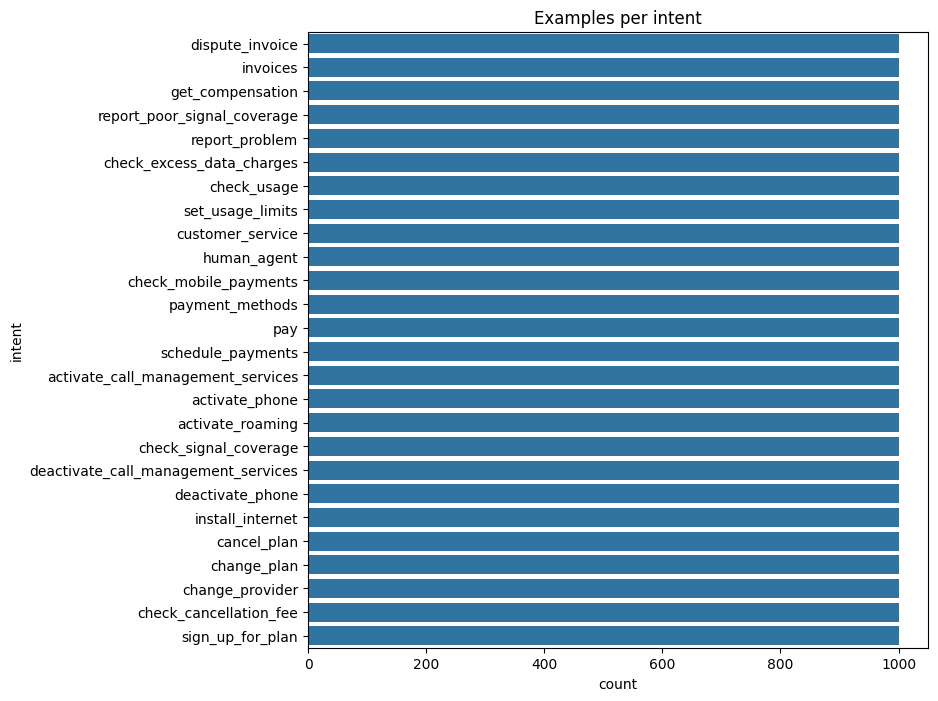

In [6]:
plt.figure(figsize=(8,8))
sns.countplot(y=df["intent"], order=df["intent"].value_counts().index)
plt.title("Examples per intent")
plt.show()


## 6. Keyword Lookup Helper
Use this **before** you assume a phrase belongs to a given intent. It tells you which intents actually contain a keyword in their training examples, and how many examples support it. If your target word barely appears anywhere, that's very likely why the model is confidently wrong on it.

In [7]:
def inspect_keyword(keyword, n=15):
    matches = df[df["instruction"].str.contains(keyword, case=False, na=False)]
    print(f'"{keyword}" appears in {len(matches)} training examples\n')
    print("Distribution across intents:")
    print(matches["intent"].value_counts())
    print()
    display(matches[["instruction", "intent"]].head(n))
    return matches

# Example: check how "slow" is represented in the dataset
_ = inspect_keyword("slow")


"slow" appears in 25 training examples

Distribution across intents:
intent
report_poor_signal_coverage    25
Name: count, dtype: int64



,instruction,intent
3032,my internet is slow id like to repot poor sign...,report_poor_signal_coverage
3076,"my internet is slow, howcan I report poor sign...",report_poor_signal_coverage
3114,"my internet is slow, I'd like to complain abou...",report_poor_signal_coverage
3167,"my internet is slow, how do I report poor sign...",report_poor_signal_coverage
3170,my internet is slow i have to complain about p...,report_poor_signal_coverage
3205,my internet is slow i need to complain about p...,report_poor_signal_coverage
3218,my internet is slow i need to complakn about p...,report_poor_signal_coverage
3230,"my internet is slow, I need to report poor sig...",report_poor_signal_coverage
3254,"my internet is slow , I have to complain about...",report_poor_signal_coverage
3308,my internet is slow hw do i complain about poo...,report_poor_signal_coverage


## 7. Data Cleaning & Label Encoding

In [8]:
df = df.drop_duplicates().dropna()
df["instruction"] = df["instruction"].str.lower()
labels = sorted(df.intent.unique())
label2id = {l: i for i, l in enumerate(labels)}
id2label = {i: l for l, i in label2id.items()}
df["label"] = df["intent"].map(label2id)
print(f"{len(labels)} intents:", labels)


26 intents: ['activate_call_management_services', 'activate_phone', 'activate_roaming', 'cancel_plan', 'change_plan', 'change_provider', 'check_cancellation_fee', 'check_excess_data_charges', 'check_mobile_payments', 'check_signal_coverage', 'check_usage', 'customer_service', 'deactivate_call_management_services', 'deactivate_phone', 'dispute_invoice', 'get_compensation', 'human_agent', 'install_internet', 'invoices', 'pay', 'payment_methods', 'report_poor_signal_coverage', 'report_problem', 'schedule_payments', 'set_usage_limits', 'sign_up_for_plan']


## 8. Train/Test Split & Tokenization

In [9]:
train_texts, test_texts, train_labels, test_labels = train_test_split(
    df["instruction"], df["label"], test_size=0.2, random_state=42, stratify=df["label"]
)

tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")
train_enc = tokenizer(list(train_texts), truncation=True, padding=True, max_length=64)
test_enc = tokenizer(list(test_texts), truncation=True, padding=True, max_length=64)

train_ds = Dataset.from_dict(train_enc).add_column("labels", list(train_labels))
test_ds = Dataset.from_dict(test_enc).add_column("labels", list(test_labels))


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

## 9. Leakage Check: Near-Duplicate Templates Across Train/Test
Bitext data is heavily templated, so exact `drop_duplicates()` isn't enough — many near-identical sentences (same template, one word swapped) can end up split across train and test. That inflates your eval accuracy without reflecting real generalization. This cell samples pairs and estimates how big the problem is.

In [10]:
def near_duplicate_rate(train_texts, test_texts, sample_train=800, sample_test=80, threshold=0.9, seed=1):
    tr_sample = pd.Series(train_texts).sample(min(sample_train, len(train_texts)), random_state=seed).tolist()
    te_sample = pd.Series(test_texts).sample(min(sample_test, len(test_texts)), random_state=seed).tolist()
    near_dupes = 0
    for t in te_sample:
        if any(SequenceMatcher(None, t, tr).ratio() > threshold for tr in tr_sample):
            near_dupes += 1
    rate = near_dupes / len(te_sample)
    print(f"{near_dupes}/{len(te_sample)} sampled test examples ({rate:.0%}) are near-duplicates "
          f"(similarity > {threshold}) of a sampled train example.")
    print("If this is high, your test accuracy below is optimistic and won't reflect real-world phrasing.")
    return rate

_ = near_duplicate_rate(train_texts, test_texts)


13/80 sampled test examples (16%) are near-duplicates (similarity > 0.9) of a sampled train example.
If this is high, your test accuracy below is optimistic and won't reflect real-world phrasing.


## 10. Build and Train DistilBERT

In [11]:
model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased", num_labels=len(labels), id2label=id2label, label2id=label2id
)

acc = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels_ = eval_pred
    preds = np.argmax(logits, axis=-1)
    return acc.compute(predictions=preds, references=labels_)

args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=4,
    weight_decay=0.01,
    load_best_model_at_end=True,
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    compute_metrics=compute_metrics,
)

trainer.train()
trainer.evaluate()


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training Loss,Validation Loss,Epoch,Accuracy
0.000595,0.001746,4,0.999615


{'eval_loss': 0.0017461769748479128, 'eval_accuracy': 0.9996153846153846}

## 11. Evaluate the Model (full report + confusion matrix)

                                     precision    recall  f1-score   support

  activate_call_management_services       1.00      0.99      1.00       200
                     activate_phone       1.00      0.99      1.00       200
                   activate_roaming       1.00      1.00      1.00       200
                        cancel_plan       1.00      1.00      1.00       200
                        change_plan       1.00      1.00      1.00       200
                    change_provider       1.00      1.00      1.00       200
             check_cancellation_fee       1.00      1.00      1.00       200
          check_excess_data_charges       1.00      1.00      1.00       200
              check_mobile_payments       1.00      1.00      1.00       200
              check_signal_coverage       1.00      1.00      1.00       200
                        check_usage       1.00      1.00      1.00       200
                   customer_service       1.00      1.00      1.00       20

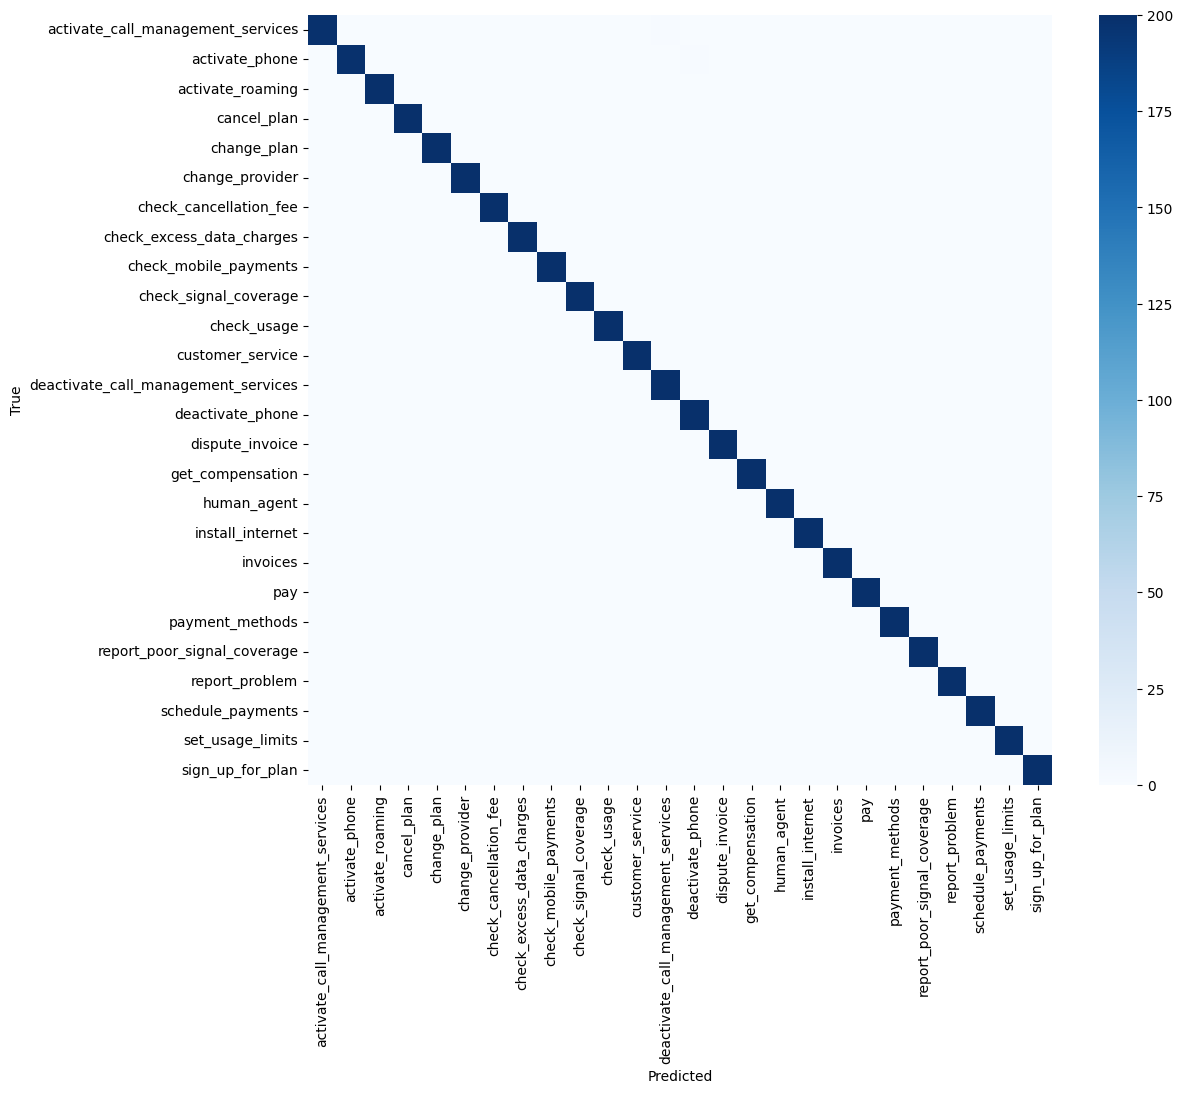

In [12]:
preds = np.argmax(trainer.predict(test_ds).predictions, axis=1)

print(classification_report(test_labels, preds, target_names=labels))

cm = confusion_matrix(test_labels, preds)
plt.figure(figsize=(12,10))
sns.heatmap(cm, xticklabels=labels, yticklabels=labels, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()


## 12. Inspect Misclassified Examples
Don't just trust the accuracy number — read what's actually being confused. This tells you whether errors are genuine ambiguity (two reasonable intents) or the model just hasn't learned a pattern.

In [13]:
test_texts_reset = test_texts.reset_index(drop=True)
test_labels_reset = test_labels.reset_index(drop=True)

wrong_idx = np.where(preds != test_labels_reset.values)[0]
print(f"{len(wrong_idx)} / {len(test_labels_reset)} test examples misclassified\n")

for i in wrong_idx[:20]:
    print(f"TEXT: {test_texts_reset[i]}")
    print(f"TRUE: {labels[test_labels_reset[i]]}  |  PRED: {labels[preds[i]]}")
    print("-" * 60)


2 / 5200 test examples misclassified

TEXT: i want to turn no voicemail, how can i do it?
TRUE: activate_call_management_services  |  PRED: deactivate_call_management_services
------------------------------------------------------------
TEXT: i need to azctivate a phone, where do i do it?
TRUE: activate_phone  |  PRED: deactivate_phone
------------------------------------------------------------


## 13. Save the Model

In [14]:
trainer.save_model("mobilis_intent_model")
tokenizer.save_pretrained("mobilis_intent_model")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('mobilis_intent_model/tokenizer_config.json',
 'mobilis_intent_model/tokenizer.json')

## 14. Inference with Confidence Fallback
Key change from the original: if the model isn't confident, don't hand a wrong intent label to the downstream LLM/RAG step. Fall back to `"unknown"` and let the next stage handle it generically (e.g. broader retrieval, or ask a clarifying question).

In [18]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [19]:
import shutil

shutil.copytree(
    "/content/mobilis_intent_model",
    "/content/drive/MyDrive/mobilis_intent_model",
    dirs_exist_ok=True
)

print("Model copied to Google Drive")

Model copied to Google Drive
